# Simulated Annealing para distribuci?n de combustibles

Notebook generado a partir de `simulated_annealing_combustibles.py`.


In [29]:
import copy
import math
import random
from typing import Dict, List, Tuple, Any




## DATOS DEL PROBLEMA


In [30]:
CAMIONES = {
    "T1": {
        "capacidad": {"C0": 8000, "C1": 7000},
        "costo_fijo": 500,
        "velocidad": 60,       # km/h
        "salida": "05:00"
    },
    "T2": {
        "capacidad": {"C0": 6000, "C1": 9000},
        "costo_fijo": 400,
        "velocidad": 60,       # km/h
        "salida": "05:30"
    }
}

DEMANDAS = {
    1: {"R": 3000, "D": 2000},
    2: {"R": 4000, "D": 1500},
    3: {"R": 2500, "D": 3000},
    4: {"R": 1000, "D": 2500}
}

VENTANAS = {
    1: ("06:00", "10:00"),
    2: ("07:00", "12:00"),
    3: ("08:00", "14:00"),
    4: ("06:00", "11:00")
}

DISTANCIAS = {
    (0, 1): 20, (0, 2): 35, (0, 3): 15, (0, 4): 40,
    (1, 0): 20, (2, 0): 35, (3, 0): 15, (4, 0): 40,

    (1, 2): 10, (2, 1): 10,
    (1, 3): 25, (3, 1): 25,
    (1, 4): 30, (4, 1): 30,

    (2, 3): 20, (3, 2): 20,
    (2, 4): 15, (4, 2): 15,

    (3, 4): 30, (4, 3): 30
}

PRODUCTOS = ["R", "D"]
COMPARTIMENTOS = ["C0", "C1"]
ESTACIONES = [1, 2, 3, 4]

COSTO_KM = 2
COSTO_SHORTAGE = 10
TIEMPO_SERVICIO = 30  # minutos
DELTA_MAX = 0.30

# Penalizaciones grandes para forzar factibilidad
LAMBDA_CAPACIDAD = 10_000
LAMBDA_ESTABILIDAD = 50_000
LAMBDA_TIEMPO = 1_000
LAMBDA_DUPLICADOS = 100_000
LAMBDA_ESTACIONES_NO_ASIGNADAS = 100_000




## UTILIDADES


In [31]:
def hora_a_minutos(hora: str) -> int:
    """Convierte una hora HH:MM a minutos desde las 00:00."""
    h, m = hora.split(":")
    return int(h) * 60 + int(m)


def minutos_a_hora(minutos: float) -> str:
    """Convierte minutos desde las 00:00 a formato HH:MM."""
    minutos = int(round(minutos))
    h = minutos // 60
    m = minutos % 60
    return f"{h:02d}:{m:02d}"


def distancia_ruta(ruta: List[int]) -> float:
    """
    Calcula la distancia total de una ruta:
    Depósito -> estaciones -> Depósito.
    """
    if not ruta:
        return 0

    distancia = 0
    nodo_actual = 0

    for estacion in ruta:
        distancia += DISTANCIAS[(nodo_actual, estacion)]
        nodo_actual = estacion

    distancia += DISTANCIAS[(nodo_actual, 0)]
    return distancia


def estaciones_en_solucion(solucion: Dict[str, Any]) -> List[int]:
    """Retorna todas las estaciones presentes en las rutas."""
    estaciones = []
    for datos in solucion.values():
        estaciones.extend(datos["ruta"])
    return estaciones




## REPRESENTACIÓN Y SOLUCIÓN INICIAL


In [32]:
def generar_solucion_inicial() -> Dict[str, Any]:
    """
    Solución inicial basada en la propuesta del operador:
    T1: Depósito -> 1 -> 3 -> Depósito
    T2: Depósito -> 2 -> 4 -> Depósito
    """
    return {
        "T1": {
            "ruta": [1, 3],
            "asignacion": {"C0": "R", "C1": "D"}
        },
        "T2": {
            "ruta": [2, 4],
            "asignacion": {"C0": "D", "C1": "R"}
        }
    }


def normalizar_solucion(solucion: Dict[str, Any]) -> Dict[str, Any]:
    """
    Corrige duplicados y estaciones perdidas para mantener una solución estructuralmente válida.
    No garantiza factibilidad de capacidad, estabilidad ni tiempo.
    """
    nueva = copy.deepcopy(solucion)

    vistas = set()
    duplicadas = []

    for camion in nueva:
        ruta_limpia = []
        for estacion in nueva[camion]["ruta"]:
            if estacion not in vistas:
                ruta_limpia.append(estacion)
                vistas.add(estacion)
            else:
                duplicadas.append(estacion)
        nueva[camion]["ruta"] = ruta_limpia

    faltantes = [e for e in ESTACIONES if e not in vistas]

    for estacion in faltantes:
        camion = random.choice(list(nueva.keys()))
        pos = random.randint(0, len(nueva[camion]["ruta"]))
        nueva[camion]["ruta"].insert(pos, estacion)

    return nueva




## CÁLCULO DE ENTREGAS Y CARGAS


In [33]:
def calcular_demanda_por_producto(ruta: List[int]) -> Dict[str, float]:
    """Calcula la demanda total Regular y Diésel de una ruta."""
    total = {"R": 0, "D": 0}

    for estacion in ruta:
        total["R"] += DEMANDAS[estacion]["R"]
        total["D"] += DEMANDAS[estacion]["D"]

    return total


def asignar_cargas_a_compartimentos(solucion: Dict[str, Any]) -> Tuple[Dict[str, Dict[str, float]], float]:
    """
    Calcula la carga inicial de cada compartimento según la ruta y asignación.

    Si un producto no tiene compartimento asignado en un camión que visita estaciones
    con demanda de ese producto, esa demanda se considera shortage.

    Si un producto tiene más de un compartimento asignado, se distribuye de manera
    simple usando la capacidad disponible.
    """
    cargas_por_camion = {}
    shortage = 0

    for camion, datos in solucion.items():
        ruta = datos["ruta"]
        asignacion = datos["asignacion"]
        capacidades = CAMIONES[camion]["capacidad"]

        cargas = {"C0": 0, "C1": 0}
        demanda_producto = calcular_demanda_por_producto(ruta)

        for producto in PRODUCTOS:
            compartimentos_producto = [
                c for c in COMPARTIMENTOS
                if asignacion[c] == producto
            ]

            demanda = demanda_producto[producto]

            if demanda == 0:
                continue

            if not compartimentos_producto:
                shortage += demanda
                continue

            restante = demanda

            for c in compartimentos_producto:
                espacio = capacidades[c] - cargas[c]
                asignado = min(restante, espacio)
                cargas[c] += asignado
                restante -= asignado

            if restante > 0:
                # No alcanzó la capacidad para cubrir todo el producto
                shortage += restante

        cargas_por_camion[camion] = cargas

    return cargas_por_camion, shortage


def producto_de_compartimento(solucion: Dict[str, Any], camion: str, compartimento: str) -> str:
    return solucion[camion]["asignacion"][compartimento]




## COSTOS


In [34]:
def costo_distancia(solucion: Dict[str, Any]) -> float:
    total = 0

    for camion, datos in solucion.items():
        ruta = datos["ruta"]
        total += distancia_ruta(ruta) * COSTO_KM

    return total


def costo_fijo(solucion: Dict[str, Any]) -> float:
    total = 0

    for camion, datos in solucion.items():
        if datos["ruta"]:
            total += CAMIONES[camion]["costo_fijo"]

    return total


def costo_shortage(shortage_litros: float) -> float:
    return shortage_litros * COSTO_SHORTAGE




## PENALIZACIONES DE FACTIBILIDAD


In [35]:
def penalizacion_capacidad(solucion: Dict[str, Any]) -> float:
    """
    Penaliza excesos de capacidad.
    En la función de carga ya se intenta no superar capacidad, por lo que esta
    penalización normalmente será cero. Se mantiene para robustez.
    """
    cargas, _ = asignar_cargas_a_compartimentos(solucion)
    exceso = 0

    for camion in solucion:
        for c in COMPARTIMENTOS:
            capacidad = CAMIONES[camion]["capacidad"][c]
            if cargas[camion][c] > capacidad:
                exceso += cargas[camion][c] - capacidad

    return exceso


def penalizacion_estabilidad(solucion: Dict[str, Any]) -> float:
    """
    Penaliza diferencias de fill ratio mayores a DELTA_MAX.
    Se evalúa al salir del depósito y después de cada entrega.
    """
    cargas_iniciales, _ = asignar_cargas_a_compartimentos(solucion)
    penalizacion = 0

    for camion, datos in solucion.items():
        ruta = datos["ruta"]
        asignacion = datos["asignacion"]
        capacidades = CAMIONES[camion]["capacidad"]

        cargas = copy.deepcopy(cargas_iniciales[camion])

        def diferencia_fill_ratio() -> float:
            fr_c0 = cargas["C0"] / capacidades["C0"]
            fr_c1 = cargas["C1"] / capacidades["C1"]
            return abs(fr_c0 - fr_c1)

        # Estado inicial
        dif = diferencia_fill_ratio()
        if dif > DELTA_MAX:
            penalizacion += dif - DELTA_MAX

        # Estados después de cada estación
        for estacion in ruta:
            for c in COMPARTIMENTOS:
                producto = asignacion[c]
                demanda_producto = DEMANDAS[estacion][producto]

                entrega = min(cargas[c], demanda_producto)
                cargas[c] -= entrega

            dif = diferencia_fill_ratio()
            if dif > DELTA_MAX:
                penalizacion += dif - DELTA_MAX

    return penalizacion


def penalizacion_ventanas_tiempo(solucion: Dict[str, Any]) -> float:
    """
    Penaliza llegadas fuera de ventana de tiempo.
    Si llega antes, se permite esperar, por lo que no se penaliza llegar temprano.
    Se penaliza solo llegar después del cierre de ventana.
    """
    penalizacion = 0

    for camion, datos in solucion.items():
        ruta = datos["ruta"]

        if not ruta:
            continue

        velocidad = CAMIONES[camion]["velocidad"]
        tiempo_actual = hora_a_minutos(CAMIONES[camion]["salida"])
        nodo_actual = 0

        for estacion in ruta:
            tiempo_viaje = (DISTANCIAS[(nodo_actual, estacion)] / velocidad) * 60
            llegada = tiempo_actual + tiempo_viaje

            inicio = hora_a_minutos(VENTANAS[estacion][0])
            fin = hora_a_minutos(VENTANAS[estacion][1])

            if llegada > fin:
                penalizacion += llegada - fin

            # Si llega antes, espera hasta que abra la ventana
            inicio_servicio = max(llegada, inicio)
            tiempo_actual = inicio_servicio + TIEMPO_SERVICIO
            nodo_actual = estacion

    return penalizacion


def penalizacion_estaciones(solucion: Dict[str, Any]) -> float:
    """
    Penaliza estaciones duplicadas o no asignadas.
    """
    estaciones = estaciones_en_solucion(solucion)

    faltantes = len(set(ESTACIONES) - set(estaciones))
    duplicados = len(estaciones) - len(set(estaciones))

    return faltantes + duplicados




## EVALUACIÓN TOTAL


In [36]:
def evaluar_solucion(solucion: Dict[str, Any]) -> Dict[str, float]:
    """
    Retorna desglose completo de costos y penalizaciones.
    """
    cargas, shortage_litros = asignar_cargas_a_compartimentos(solucion)

    c_dist = costo_distancia(solucion)
    c_fijo = costo_fijo(solucion)
    c_short = costo_shortage(shortage_litros)

    p_cap = penalizacion_capacidad(solucion)
    p_est = penalizacion_estabilidad(solucion)
    p_time = penalizacion_ventanas_tiempo(solucion)
    p_estaciones = penalizacion_estaciones(solucion)

    penalizacion_total = (
        LAMBDA_CAPACIDAD * p_cap +
        LAMBDA_ESTABILIDAD * p_est +
        LAMBDA_TIEMPO * p_time +
        LAMBDA_ESTACIONES_NO_ASIGNADAS * p_estaciones
    )

    costo_total = c_dist + c_fijo + c_short + penalizacion_total

    return {
        "costo_total": costo_total,
        "costo_distancia": c_dist,
        "costo_fijo": c_fijo,
        "shortage_litros": shortage_litros,
        "costo_shortage": c_short,
        "penalizacion_capacidad": p_cap,
        "penalizacion_estabilidad": p_est,
        "penalizacion_tiempo": p_time,
        "penalizacion_estaciones": p_estaciones,
        "penalizacion_total": penalizacion_total
    }




## GENERACIÓN DE VECINOS


In [37]:
def generar_vecino(solucion: Dict[str, Any]) -> Dict[str, Any]:
    """
    Genera una solución vecina usando uno de cuatro movimientos:
    1. swap: intercambiar estaciones entre camiones.
    2. move: mover estación de un camión a otro.
    3. reverse: invertir ruta de un camión.
    4. asignacion: intercambiar productos entre C0 y C1.
    """
    vecino = copy.deepcopy(solucion)
    movimiento = random.choice(["swap", "move", "reverse", "asignacion"])

    camiones = list(vecino.keys())

    if movimiento == "swap":
        c1, c2 = random.sample(camiones, 2)

        if vecino[c1]["ruta"] and vecino[c2]["ruta"]:
            i = random.randrange(len(vecino[c1]["ruta"]))
            j = random.randrange(len(vecino[c2]["ruta"]))

            vecino[c1]["ruta"][i], vecino[c2]["ruta"][j] = (
                vecino[c2]["ruta"][j],
                vecino[c1]["ruta"][i]
            )

    elif movimiento == "move":
        c1, c2 = random.sample(camiones, 2)

        if vecino[c1]["ruta"]:
            i = random.randrange(len(vecino[c1]["ruta"]))
            estacion = vecino[c1]["ruta"].pop(i)

            pos = random.randint(0, len(vecino[c2]["ruta"]))
            vecino[c2]["ruta"].insert(pos, estacion)

    elif movimiento == "reverse":
        camion = random.choice(camiones)

        if len(vecino[camion]["ruta"]) >= 2:
            vecino[camion]["ruta"].reverse()

    elif movimiento == "asignacion":
        camion = random.choice(camiones)

        vecino[camion]["asignacion"]["C0"], vecino[camion]["asignacion"]["C1"] = (
            vecino[camion]["asignacion"]["C1"],
            vecino[camion]["asignacion"]["C0"]
        )

    return normalizar_solucion(vecino)




## SIMULATED ANNEALING


In [38]:
def simulated_annealing(
    solucion_inicial: Dict[str, Any],
    temperatura_inicial: float = 1000,
    temperatura_final: float = 0.01,
    alpha: float = 0.95,
    iteraciones_por_temperatura: int = 100,
    semilla: int = 42
) -> Tuple[Dict[str, Any], Dict[str, float], List[Dict[str, Any]]]:
    """
    Ejecuta Simulated Annealing y retorna la mejor solución encontrada.
    """
    random.seed(semilla)

    solucion_actual = copy.deepcopy(solucion_inicial)
    solucion_actual = normalizar_solucion(solucion_actual)

    eval_actual = evaluar_solucion(solucion_actual)
    costo_actual = eval_actual["costo_total"]

    mejor_solucion = copy.deepcopy(solucion_actual)
    mejor_eval = copy.deepcopy(eval_actual)
    mejor_costo = costo_actual

    T = temperatura_inicial
    historial = []
    iteracion = 0

    while T > temperatura_final:
        for _ in range(iteraciones_por_temperatura):
            vecino = generar_vecino(solucion_actual)
            eval_vecino = evaluar_solucion(vecino)
            costo_vecino = eval_vecino["costo_total"]

            delta = costo_vecino - costo_actual

            if delta < 0:
                solucion_actual = vecino
                eval_actual = eval_vecino
                costo_actual = costo_vecino
            else:
                probabilidad = math.exp(-delta / T)
                if random.random() < probabilidad:
                    solucion_actual = vecino
                    eval_actual = eval_vecino
                    costo_actual = costo_vecino

            if costo_actual < mejor_costo:
                mejor_solucion = copy.deepcopy(solucion_actual)
                mejor_eval = copy.deepcopy(eval_actual)
                mejor_costo = costo_actual

            historial.append({
                "iteracion": iteracion,
                "temperatura": T,
                "costo_actual": costo_actual,
                "mejor_costo": mejor_costo
            })
            iteracion += 1

        T *= alpha

    return mejor_solucion, mejor_eval, historial


## REPORTE DE SOLUCIÓN


In [39]:
def calcular_llegadas(solucion: Dict[str, Any]) -> Dict[str, List[Tuple[int, str]]]:
    """
    Calcula las horas de llegada por camión.
    """
    llegadas = {}

    for camion, datos in solucion.items():
        ruta = datos["ruta"]
        velocidad = CAMIONES[camion]["velocidad"]

        tiempo_actual = hora_a_minutos(CAMIONES[camion]["salida"])
        nodo_actual = 0

        llegadas[camion] = []

        for estacion in ruta:
            tiempo_viaje = (DISTANCIAS[(nodo_actual, estacion)] / velocidad) * 60
            llegada = tiempo_actual + tiempo_viaje

            inicio = hora_a_minutos(VENTANAS[estacion][0])
            inicio_servicio = max(llegada, inicio)

            llegadas[camion].append((estacion, minutos_a_hora(llegada)))

            tiempo_actual = inicio_servicio + TIEMPO_SERVICIO
            nodo_actual = estacion

    return llegadas


def imprimir_solucion(solucion: Dict[str, Any], evaluacion: Dict[str, float]) -> None:
    """
    Imprime la solución de forma legible.
    """
    print("\n==============================")
    print("MEJOR SOLUCIÓN ENCONTRADA")
    print("==============================")

    cargas, shortage = asignar_cargas_a_compartimentos(solucion)
    llegadas = calcular_llegadas(solucion)

    for camion, datos in solucion.items():
        ruta = datos["ruta"]
        asignacion = datos["asignacion"]

        print(f"\nCamión {camion}")
        print(f"Ruta: Depósito -> {' -> '.join(map(str, ruta))} -> Depósito")
        print(f"Distancia: {distancia_ruta(ruta)} km")
        print(f"Asignación compartimentos: {asignacion}")
        print(f"Cargas iniciales: {cargas[camion]}")
        print("Llegadas:")

        for estacion, hora in llegadas[camion]:
            print(f"  Estación {estacion}: {hora} | Ventana {VENTANAS[estacion]}")

    print("\n------------------------------")
    print("DESGLOSE DE COSTOS")
    print("------------------------------")
    for clave, valor in evaluacion.items():
        print(f"{clave}: {valor:.2f}")




## EJECUCIÓN PRINCIPAL


In [40]:
solucion_inicial = generar_solucion_inicial()

mejor_solucion, mejor_eval, historial = simulated_annealing(
    solucion_inicial=solucion_inicial,
    temperatura_inicial=1000,
    temperatura_final=0.01,
    alpha=0.95,
    iteraciones_por_temperatura=100,
    semilla=42
)

imprimir_solucion(mejor_solucion, mejor_eval)

# Tabla de costos visible en el notebook
try:
    import pandas as pd
    display(pd.DataFrame(mejor_eval.items(), columns=["concepto", "valor"]))
except ImportError:
    mejor_eval



MEJOR SOLUCIÓN ENCONTRADA

Camión T1
Ruta: Depósito -> 1 -> 2 -> 4 -> Depósito
Distancia: 85 km
Asignación compartimentos: {'C0': 'R', 'C1': 'D'}
Cargas iniciales: {'C0': 8000, 'C1': 6000}
Llegadas:
  Estación 1: 05:20 | Ventana ('06:00', '10:00')
  Estación 2: 06:40 | Ventana ('07:00', '12:00')
  Estación 4: 07:45 | Ventana ('06:00', '11:00')

Camión T2
Ruta: Depósito -> 3 -> Depósito
Distancia: 30 km
Asignación compartimentos: {'C0': 'D', 'C1': 'R'}
Cargas iniciales: {'C0': 3000, 'C1': 2500}
Llegadas:
  Estación 3: 05:45 | Ventana ('08:00', '14:00')

------------------------------
DESGLOSE DE COSTOS
------------------------------
costo_total: 1130.00
costo_distancia: 230.00
costo_fijo: 900.00
shortage_litros: 0.00
costo_shortage: 0.00
penalizacion_capacidad: 0.00
penalizacion_estabilidad: 0.00
penalizacion_tiempo: 0.00
penalizacion_estaciones: 0.00
penalizacion_total: 0.00


,concepto,valor
0,costo_total,1130
1,costo_distancia,230
2,costo_fijo,900
3,shortage_litros,0
4,costo_shortage,0
5,penalizacion_capacidad,0
6,penalizacion_estabilidad,0
7,penalizacion_tiempo,0
8,penalizacion_estaciones,0
9,penalizacion_total,0


## VISUALIZACIÓN DE RESULTADOS Y ANÁLISIS


### 1. Curva de Convergencia

El siguiente gráfico muestra cómo evoluciona el costo del costo total a medida que avanza el algoritmo.

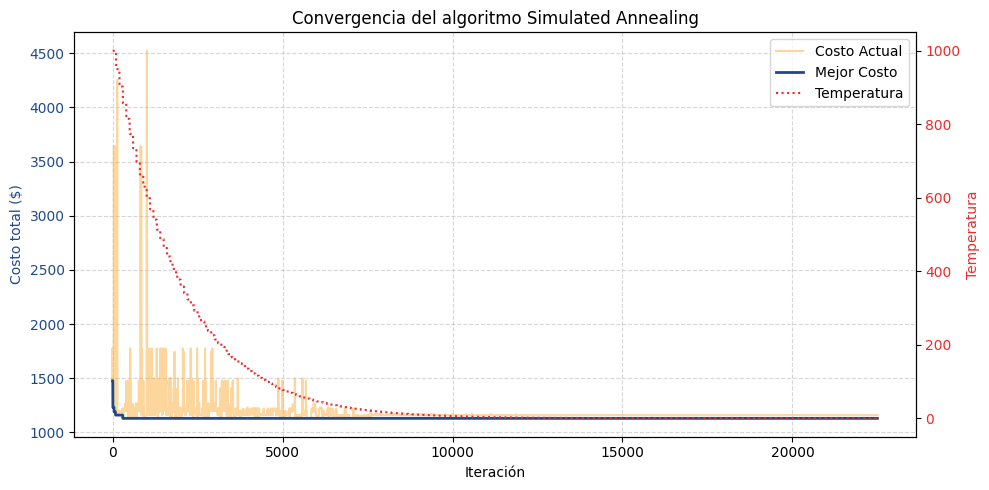

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

df_hist = pd.DataFrame(historial)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Graficar costos
ax1.plot(df_hist['iteracion'], df_hist['costo_actual'], label='Costo Actual', color='#fcaf3e', alpha=0.5)
ax1.plot(df_hist['iteracion'], df_hist['mejor_costo'], label='Mejor Costo', color='#204a87', linewidth=2)
ax1.set_xlabel('Iteración')
ax1.set_ylabel('Costo total ($)', color='#204a87')
ax1.tick_params(axis='y', labelcolor='#204a87')
ax1.grid(True, linestyle='--', alpha=0.5)

# Eje secundario para la temperatura
ax2 = ax1.twinx()
ax2.plot(df_hist['iteracion'], df_hist['temperatura'], label='Temperatura', color='#ef2929', linestyle=':')
ax2.set_ylabel('Temperatura', color='#ef2929')
ax2.tick_params(axis='y', labelcolor='#ef2929')

plt.title('Convergencia del algoritmo Simulated Annealing')
fig.tight_layout()

# Combinar leyendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.show()


### 2. Cronograma de Rutas y Ventanas de Tiempo (Diagrama de Gantt)

Este gráfico representa de forma visual el cronograma de actividades de cada camión (tiempo de viaje, espera por llegada temprana y servicio) y verifica el cumplimiento de las ventanas de tiempo requeridas por las estaciones de servicio (mostradas de fondo como bloques grises delimitados).

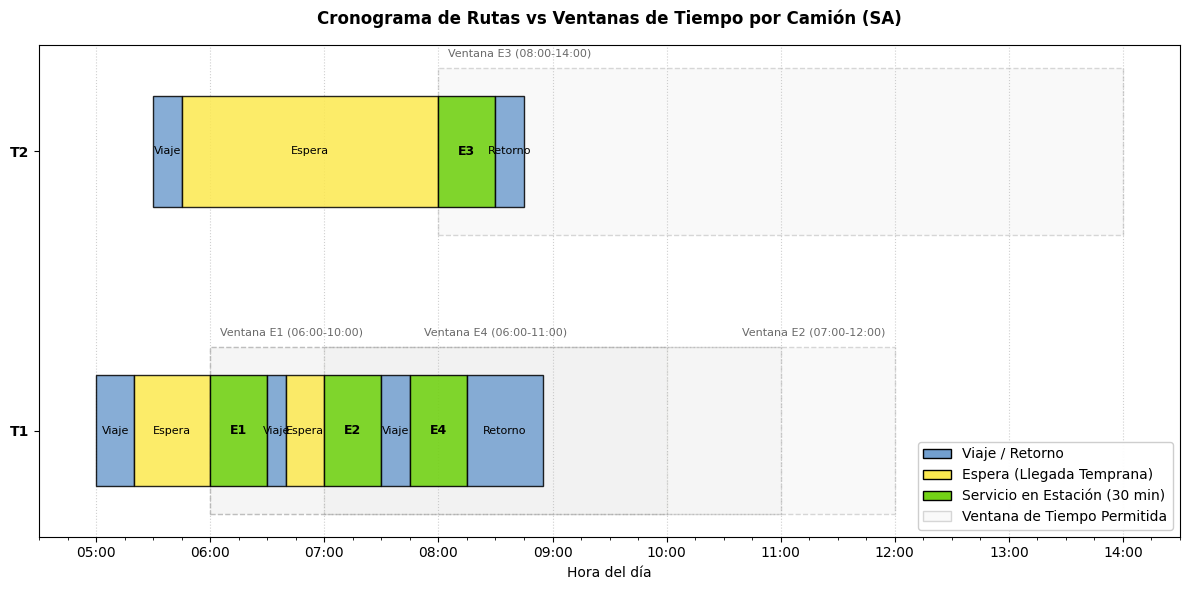

In [ ]:
def graficar_gantt_rutas(solucion):
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    from matplotlib.patches import Patch
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colores = {
        'viaje': '#729fcf',     
        'espera': '#fce94f',    
        'servicio': '#73d216',  
        'ventana': '#eeeeec'     
    }
    
    camiones = list(solucion.keys())
    coords_y = {camion: i for i, camion in enumerate(camiones)}
    
    # Dibujar las barras
    for camion, datos in solucion.items():
        ruta = datos["ruta"]
        if not ruta:
            continue
            
        velocidad = CAMIONES[camion]["velocidad"]
        tiempo_actual = hora_a_minutos(CAMIONES[camion]["salida"])
        nodo_actual = 0
        y_pos = coords_y[camion]
        
        for idx, estacion in enumerate(ruta):
            # 1. Viaje de ida/entre estaciones
            tiempo_viaje = (DISTANCIAS[(nodo_actual, estacion)] / velocidad) * 60
            llegada = tiempo_actual + tiempo_viaje
            
            ax.barh(y_pos, tiempo_viaje, left=tiempo_actual, height=0.4, 
                    color=colores['viaje'], edgecolor='black', alpha=0.85, zorder=3)
            ax.text(tiempo_actual + tiempo_viaje/2, y_pos, 'Viaje', 
                    ha='center', va='center', fontsize=8, color='black', zorder=4)
            
            tiempo_actual = llegada
            
            # Ventana de tiempo de la estación
            win_start = hora_a_minutos(VENTANAS[estacion][0])
            win_end = hora_a_minutos(VENTANAS[estacion][1])
            
            # Dibujar el fondo de la ventana
            ax.barh(y_pos, win_end - win_start, left=win_start, height=0.6, 
                    color=colores['ventana'], edgecolor='gray', linestyle='--', alpha=0.3, zorder=1)
            
            # Evitar solapamiento de etiquetas de ventanas mediante posicionamiento alternado
            if idx % 3 == 0:
                x_pos_lbl = win_start + 5
                ha_lbl = 'left'
            elif idx % 3 == 1:
                x_pos_lbl = win_end - 5
                ha_lbl = 'right'
            else:
                x_pos_lbl = (win_start + win_end) / 2
                ha_lbl = 'center'
                
            ax.text(x_pos_lbl, y_pos + 0.35, f"Ventana E{estacion} ({VENTANAS[estacion][0]}-{VENTANAS[estacion][1]})", 
                    ha=ha_lbl, va='center', fontsize=8, color='dimgray', zorder=2)
            
            # 2. Espera (si llegó temprano)
            if llegada < win_start:
                tiempo_espera = win_start - llegada
                ax.barh(y_pos, tiempo_espera, left=llegada, height=0.4,
                        color=colores['espera'], edgecolor='black', alpha=0.85, zorder=3)
                ax.text(llegada + tiempo_espera/2, y_pos, 'Espera',
                        ha='center', va='center', fontsize=8, color='black', zorder=4)
                tiempo_actual = win_start
                
            # 3. Servicio en estación
            ax.barh(y_pos, TIEMPO_SERVICIO, left=tiempo_actual, height=0.4,
                    color=colores['servicio'], edgecolor='black', alpha=0.9, zorder=3)
            ax.text(tiempo_actual + TIEMPO_SERVICIO/2, y_pos, f"E{estacion}",
                    ha='center', va='center', fontsize=9, color='black', weight='bold', zorder=4)
            
            tiempo_actual += TIEMPO_SERVICIO
            nodo_actual = estacion
            
        # Viaje de retorno al depósito
        tiempo_viaje_retorno = (DISTANCIAS[(nodo_actual, 0)] / velocidad) * 60
        ax.barh(y_pos, tiempo_viaje_retorno, left=tiempo_actual, height=0.4,
                color=colores['viaje'], edgecolor='black', alpha=0.85, zorder=3)
        ax.text(tiempo_actual + tiempo_viaje_retorno/2, y_pos, 'Retorno',
                ha='center', va='center', fontsize=8, color='black', zorder=4)
                
    # Etiquetas y formato
    ax.set_yticks(range(len(camiones)))
    ax.set_yticklabels(camiones, fontsize=10, weight='bold')
    ax.set_xlabel('Hora del día', fontsize=10)
    ax.set_title('Cronograma de Rutas vs Ventanas de Tiempo por Camión (SA)', fontsize=12, weight='bold', pad=15)
    
    # Configurar el eje X para mostrar en formato HH:MM
    ax.xaxis.set_major_locator(ticker.MultipleLocator(60)) 
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(15)) 
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x)//60:02d}:{int(x)%60:02d}"))
    
    # Línea de cuadrícula
    ax.grid(axis='x', linestyle=':', alpha=0.6, zorder=0)
    
    # Crear la leyenda personalizada
    legend_patches = [
        Patch(facecolor=colores['viaje'], edgecolor='black', label='Viaje / Retorno'),
        Patch(facecolor=colores['espera'], edgecolor='black', label='Espera (Llegada Temprana)'),
        Patch(facecolor=colores['servicio'], edgecolor='black', label='Servicio en Estación (30 min)'),
        Patch(facecolor=colores['ventana'], edgecolor='gray', alpha=0.3, label='Ventana de Tiempo Permitida')
    ]
    ax.legend(handles=legend_patches, loc='lower right', framealpha=0.95)
    
    # Ajustar límites del eje X con holgura
    min_time = min(hora_a_minutos(c["salida"]) for c in CAMIONES.values()) - 30
    max_time = max(hora_a_minutos(v[1]) for v in VENTANAS.values()) + 30
    ax.set_xlim(min_time, max_time)
    
    plt.tight_layout()
    plt.show()

graficar_gantt_rutas(mejor_solucion)


### 3. Mapa de Rutas de los Camiones

El siguiente gráfico representa de forma esquemática la ruta tomada por cada camión, mostrando el orden de visita (secuencia) a las estaciones de servicio partiendo y regresando al depósito central.

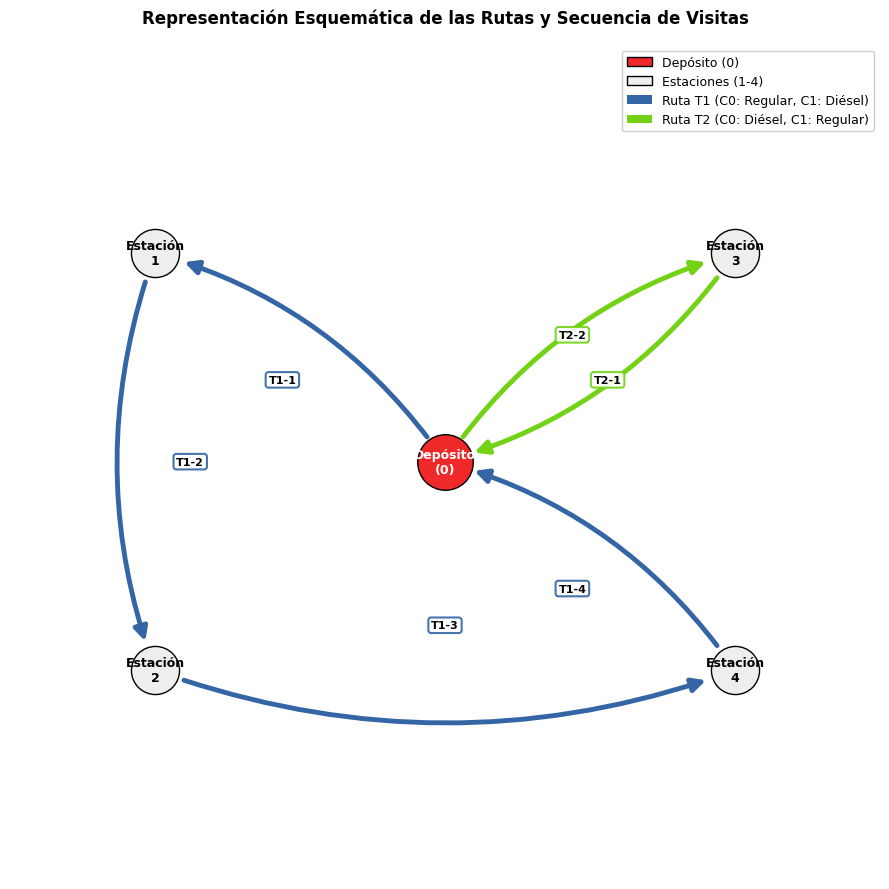

In [43]:
def graficar_rutas_2d(solucion):
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.patches import Patch
    
    fig, ax = plt.subplots(figsize=(9, 9))
    
    # Coordenadas esquemáticas de los nodos
    pos = {
        0: (0, 0),        # Depósito
        1: (-2, 1.5),     # Estación 1
        2: (-2, -1.5),    # Estación 2
        3: (2, 1.5),      # Estación 3
        4: (2, -1.5)      # Estación 4
    }
    
    # Dibujar Depósito
    ax.scatter(pos[0][0], pos[0][1], s=1600, color='#ef2929', edgecolor='black', zorder=5)
    ax.text(pos[0][0], pos[0][1], 'Depósito\n(0)', ha='center', va='center', color='white', weight='bold', fontsize=9, zorder=6)
    
    # Dibujar Estaciones
    for e in ESTACIONES:
        ax.scatter(pos[e][0], pos[e][1], s=1200, color='#eeeeec', edgecolor='black', zorder=5)
        ax.text(pos[e][0], pos[e][1], f"Estación\n{e}", ha='center', va='center', color='black', weight='bold', fontsize=9, zorder=6)
        
    colores = {
        'T1': '#3465a4',  # Azul
        'T2': '#73d216'   # Verde
    }
    
    # Dibujar rutas
    for camion, datos in solucion.items():
        ruta = datos["ruta"]
        if not ruta:
            continue
            
        color = colores[camion]
        full_route = [0] + ruta + [0]
        
        # Curvatura: T1 curva a la izquierda (positivo), T2 a la derecha (negativo)
        rad = 0.18 if camion == 'T1' else -0.18
        
        for i in range(len(full_route) - 1):
            u, v = full_route[i], full_route[i+1]
            
            # Dibujar la flecha curva
            ax.annotate("",
                        xy=pos[v], xytext=pos[u],
                        arrowprops=dict(
                            arrowstyle="-|>",
                            color=color,
                            lw=3.5,
                            connectionstyle=f"arc3,rad={rad}",
                            mutation_scale=20,
                            shrinkA=22,
                            shrinkB=22
                        ),
                        zorder=3
            )
            
            # Calcular punto medio con deflexión para colocar el número de secuencia
            xu, yu = pos[u]
            xv, yv = pos[v]
            mid_x, mid_y = (xu + xv) / 2, (yu + yv) / 2
            dx, dy = xv - xu, yv - yu
            L = np.sqrt(dx**2 + dy**2)
            
            if L > 0:
                # Desplazamiento ortogonal proporcional a la curvatura
                offset_x = -dy/L * L * rad * 0.45
                offset_y = dx/L * L * rad * 0.45
                lbl_x = mid_x + offset_x
                lbl_y = mid_y + offset_y
                
                # Dibujar etiqueta de secuencia con fondo blanco redondo
                ax.text(lbl_x, lbl_y, f"{camion}-{i+1}", ha='center', va='center', fontsize=8, weight='bold', color='black',
                        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec=color, lw=1.5, alpha=0.9), zorder=4)
                
    legend_patches = [
        Patch(facecolor='#ef2929', edgecolor='black', label='Depósito (0)'),
        Patch(facecolor='#eeeeec', edgecolor='black', label='Estaciones (1-4)'),
        Patch(facecolor=colores['T1'], label='Ruta T1 (C0: Regular, C1: Diésel)'),
        Patch(facecolor=colores['T2'], label='Ruta T2 (C0: Diésel, C1: Regular)')
    ]
    ax.legend(handles=legend_patches, loc='upper right', framealpha=0.95, fontsize=9)
    ax.set_title('Representación Esquemática de las Rutas y Secuencia de Visitas', fontsize=12, weight='bold', pad=15)
    ax.axis('off')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    plt.tight_layout()
    plt.show()

graficar_rutas_2d(mejor_solucion)
